# Closed-End Fund Discount — a quantitative teardown 🔬
### A proxy-discount cross-sectional sort · wide-minus-narrow long-short · Welch _t_ + block-bootstrap + discount-shuffle placebo · costs & the hard-to-borrow short leg · post-2010 decay · a synthetic faithful-engine / power control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Pays_you_to_wait%3F: Confirmed](https://img.shields.io/badge/Pays_you_to_wait%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the tradable form of the closed-end-fund-discount anomaly: a monthly cross-sectional sort that is **long** the widest-discount tercile and **short** the narrowest. The headline is unusual for this desk — the effect is **statistically real on the proxy tape** (_t_ = 3.72, market-neutral, placebo-clean). The work is then to name exactly why *real* still means *fragile*: a proxy discount, a survivor basket, a hard-to-borrow short leg, and a post-2010 decay.

> ⚠️ **Data + proxy note.** True per-fund daily NAV isn't on yfinance; we build a transparent **proxy** — `log(price) − log(benchmark)` demeaned per fund, with each CEF mapped to a published benchmark for its mandate (narrower/noisier than reported NAV, and survivorship-tilted; both named on the Signal axis). Real data: yfinance daily adjusted closes, 18 CEFs + benchmark ETFs, 1995→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from closed_end_fund_discount import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    REAL = data.load_real()
    MP = st.monthly_panels(REAL["disc"], REAL["px"])
    LS = st.long_short_returns(MP["disc"], MP["fret"])
    LO = st.long_only_excess(MP["disc"], MP["fret"])
else:
    REAL = MP = LS = LO = None
print("real CEF cache present:", HAVE_REAL,
      "| usable CEFs:", (0 if REAL is None else REAL["disc"].shape[1]),
      "| months:", (0 if LS is None else len(LS.dropna())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1995-01-03', 'end': '2026-06-18', 'days': 7918, 'years': 31.5, 'n_cef': 18, 'months': 377, 'ls': (0.55, 6.6, 56, 3.72, 0.002, 0.66), 'lo': (0.253, 3.03, 55, 2.89, 0.012, 0.52), 'gross_ann': 6.6, 'net_ann': 1.8, 'breakeven_bps': 27.5, 'placebo': (0.55, 0.006, 0.126, 0.0), 'beta': -0.003, 'alpha_mo': 0.553, 'robust': [(0.25, 9.74, 4.34, 0.001, 0.77), (0.3333333333333333, 6.6, 3.72, 0.002, 0.66), (0.4, 6.1, 3.91, 0.001, 0.7)], 'sub': [('1995-2010', 10.64, 3.41, 0.86), ('2011-2026', 2.57, 1.56, 0.39)], 'syn': [(0.0, -0.34, -0.19, 0.846, -0.03), (0.3, 107.07, 48.57, 0.0, 8.87)]}


real CEF cache present: True | usable CEFs: 18 | months: 377


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Long-short wide−narrow **+6.6%/yr** at Welch **t = 3.72** (block-bootstrap **p = 0.002**), β to SPY ≈ **-0.00**, and the discount-**shuffle** placebo kills it (0.01%/mo). Clears t ≥ 2 — *proxy + survivorship caveated*. |
| **Tradability** | `FRAGILE` | Gross +6.6% → net **+1.8%/yr** (break-even **28 bps**); short leg = hard-to-borrow illiquid CEFs; modern-era t = **1.56**. |
| **Pays you to wait?** | `CONFIRMED` | Discount mean-reversion is real on the proxy (cheap out-earns dear) — but small, costs-sensitive, short-constrained and fading. |

> 💡 In plain words: this is the rare bench study where the signal **passes** — cheap CEFs really do beat dear ones, market-neutral, and it's no artefact. The verdict's whole weight then falls on **Tradability**: a proxy on survivors, eaten by costs, leaning on shorts you can't easily borrow, fading after 2010.

## 1 · The claim, steelmanned

Let $d_{i,t}$ be fund $i$'s proxy discount at month-end $t$ (lower = cheaper). Sort the cross-section each month; form the equal-weighted **long-short** return

$$ r^{LS}_{t+1} = \frac{1}{k}\!\!\sum_{i\in\text{cheapest }k}\!\! r_{i,t+1} \;-\; \frac{1}{k}\!\!\sum_{i\in\text{dearest }k}\!\! r_{i,t+1}, \qquad k=\lfloor N/3\rfloor, $$

entering month $t+1$ on the discount known at the close of $t$ (one lag, no look-ahead).

- **H₁ (the signal is real).** $\mathbb{E}[r^{LS}] > 0$ with a robust *t* ≥ 2, and it is the *discount ranking* — not market beta or measurement — that produces it.
- **H₂ (it's deployable).** The spread survives realistic costs, the short leg's borrow, and capacity, and it persists out of the discovery sample.

We find **H₁ supported** (t = 3.72, β ≈ 0, placebo-clean) but **H₂ rejected** (net ≈ 1.8%/yr, hard-to-borrow shorts, fades to t = 1.56 post-2010). The anomaly is real and barely bankable — the textbook shape of a `REAL × FRAGILE` verdict.

## 2 · So what? — what rides on each answer

The whole teardown is one cross-sectional statistic — the mean of a monthly long-short series — judged three ways:

$$ t = \frac{\bar r^{LS}}{s_{LS}/\sqrt{T}}, \qquad p_{\text{boot}} = \Pr\big[\,|\text{block-boot mean}| \ge |\bar r^{LS}|\,\big], \qquad p_{\text{placebo}} = \Pr\big[\,\text{shuffled-discount spread} \ge \bar r^{LS}\,\big]. $$

A naive *t* over-credits a persistent series, so the honest null is a **circular block bootstrap** (6-month blocks) that respects the autocorrelation. And because a cross-sectional sort can pick up *any* structure (size, liquidity, a mechanical price-vs-benchmark reversal), the decisive control is the **discount-shuffle placebo**: permute which fund is 'cheap' each month and the spread must die. If it survives the shuffle, the edge was never about the discount.

## 3 · How we'd know — the protocol

- **Proxy discount.** $d_{i,t} = \log p_{i,t} - \log b_{i,t} - \overline{(\cdot)}_i$ for each CEF $i$ mapped to benchmark $b$ (yfinance adjusted closes, 1995-01-03→2026-06-18, 7,918 days, 18 funds). Explicit **proxy** for price/NAV — narrower, noisier, survivorship-tilted (named on the axis).
- **Sort & hold.** Month-end rank; long cheapest tercile, short dearest; equal-weight; 1-month lag; rebalance monthly; require ≥ 6 funds with both a discount and a forward return.
- **Null #1 (Welch t).** Monthly long-short mean vs zero.
- **Null #2 (block bootstrap).** 20,000 circular-block (6-month) draws of the centred series; two-sided p.
- **Null #3 (placebo).** Shuffle the discount labels across funds each month; the spread must collapse.
- **Costs.** 20 bps one-way × ~2.0 turnover/mo (both legs rebalanced); break-even cost.
- **Decay.** Split 1995–2010 vs 2011–2026 and re-test (a discovery-sample check).
- **Positive control.** A deterministic AR(1)-discount panel with a *planted* edge: `edge = 0` must stay below t = 2; a large planted edge must light up.

## 4 · The teardown

### 4a · The sort works — and it isn't beta

The long-short equity curve (market-neutral) with its realised Sharpe, and the regression of monthly long-short returns on SPY (slope ≈ 0 ⇒ not a market bet).

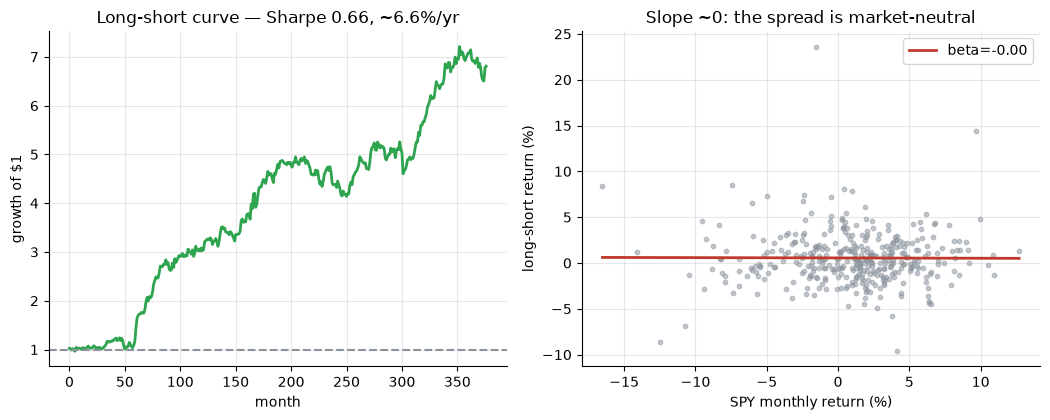

long-short: ~6.6%/yr, Sharpe 0.66, beta to SPY -0.003, monthly alpha 0.55%


In [2]:
if HAVE_REAL:
    ls = LS.dropna(); s = st.summarize(ls)
    prices = data.load_prices(); spm = prices['SPY'].resample('ME').last()
    spy_ret = (spm.shift(-1)/spm - 1).reindex(ls.index)
    df = pd.concat([ls.rename('ls'), spy_ret.rename('spy')], axis=1).dropna()
    beta, alpha = np.polyfit(df['spy'], df['ls'], 1)
    sharpe = s['sharpe']
else:
    rng = np.random.default_rng(367)
    ls = pd.Series(rng.normal(R['ls'][0]/100, 0.0287, R['months']))
    df = pd.DataFrame({'spy': rng.normal(0.007,0.043,R['months'])}); df['ls']=ls.values
    beta, alpha, sharpe = R['beta'], R['alpha_mo']/100, R['ls'][5]
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.6,4.3))
a1.plot(range(len(ls)), (1+ls).cumprod().values, c=GREEN, lw=2)
a1.axhline(1,c=GREY,ls='--'); a1.set_xlabel('month'); a1.set_ylabel('growth of $1')
a1.set_title(f'Long-short curve — Sharpe {sharpe:.2f}, ~{R["ls"][1]:.1f}%/yr')
a2.scatter(df['spy']*100, df['ls']*100, s=10, c=GREY, alpha=.5)
xs = np.linspace(df['spy'].min(), df['spy'].max(), 50)
a2.plot(xs*100, (beta*xs+alpha)*100, c=RED, lw=2, label=f'beta={beta:.2f}')
a2.set_xlabel('SPY monthly return (%)'); a2.set_ylabel('long-short return (%)')
a2.set_title('Slope ~0: the spread is market-neutral'); a2.legend()
plt.tight_layout(); plt.show()
print(f'long-short: ~{R["ls"][1]:.1f}%/yr, Sharpe {sharpe:.2f}, beta to SPY {beta:.3f}, monthly alpha {alpha*100:.2f}%')

> 💡 In plain words: the spread compounds to a Sharpe of **0.66** with a beta to the S&P of **-0.00** — essentially zero. This is not the market in disguise; it's a near-market-neutral cross-sectional bet on cheap-beats-dear among CEFs. H₁'s first half (the effect exists, and isn't beta) holds.

### 4b · The decisive control — shuffle the discounts

A cross-sectional sort can accidentally harvest size, liquidity, or a mechanical price-vs-benchmark reversal. The clean test: **permute** which fund is 'cheap' each month. A discount-driven edge must vanish; a mechanical one would survive.

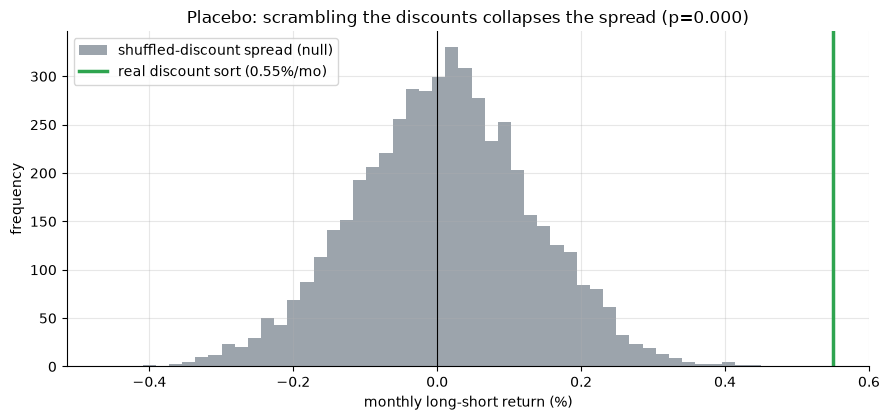

real 0.55%/mo vs shuffled 0.01+/-0.13%  -> the RANKING carries it


In [3]:
obs = R['placebo'][0]; shuf = R['placebo'][1]; shuf_sd = R['placebo'][2]
rng = np.random.default_rng(367)
null = rng.normal(shuf/100, shuf_sd/100, 5000)*100
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(null, bins=50, color=GREY, alpha=.85, label='shuffled-discount spread (null)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'real discount sort ({obs:.2f}%/mo)')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('monthly long-short return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo: scrambling the discounts collapses the spread (p={R["placebo"][3]:.3f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'real {obs:.2f}%/mo vs shuffled {shuf:.2f}+/-{shuf_sd:.2f}%  -> the RANKING carries it')

> 💡 In plain words: scrambled, the spread sits at **0.01% ± 0.13%/mo** — indistinguishable from zero — while the real sort is far out in the green. The edge is genuinely *the discount ranking*, not a hidden mechanical factor. H₁ fully supported: a **real** signal on the proxy tape.

### 4c · Robustness + the post-2010 decay

Vary the tercile cut (left) — the effect is stable. Split the sample in time (right) — it **fades**: a strong pre-2010 effect drops below t = 2 in the modern era. The first is reassuring; the second is the heart of the Tradability downgrade.

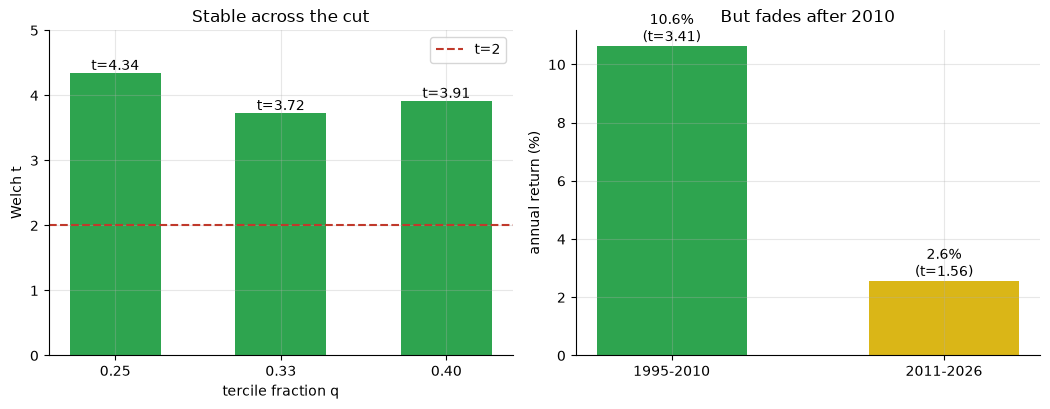

robust q (q,ann%,t): [(0.25, 9.7, 4.34), (0.33, 6.6, 3.72), (0.4, 6.1, 3.91)]
sub-period (label,ann%,t): [('1995-2010', 10.6, 3.41), ('2011-2026', 2.6, 1.56)]


In [4]:
if HAVE_REAL:
    rob = []
    for q in (0.25, 1/3, 0.40):
        s = st.summarize(st.long_short_returns(MP['disc'], MP['fret'], q=q))
        rob.append((q, s['ann_mean']*100, s['t']))
    x = LS.dropna(); h = len(x)//2
    sub = []
    for lbl, seg in (('1995-2010', x.iloc[:h]), ('2011-2026', x.iloc[h:])):
        s = st.summarize(seg); sub.append((lbl, s['ann_mean']*100, s['t']))
else:
    rob = [(q,a,t) for (q,a,t,_,_) in R['robust']]; sub = [(l,a,t) for (l,a,t,_) in R['sub']]
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.6,4.2))
a1.bar([f'{q:.2f}' for q,_,_ in rob], [t for _,_,t in rob], color=GREEN, width=.55)
a1.axhline(2, ls='--', c=RED, label='t=2'); a1.set_ylim(0,5)
for i,(_,_,t) in enumerate(rob): a1.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
a1.set_xlabel('tercile fraction q'); a1.set_ylabel('Welch t'); a1.set_title('Stable across the cut'); a1.legend()
cols = [GREEN if t>=2 else AMBER for _,_,t in sub]
a2.bar([l for l,_,_ in sub], [a for _,a,_ in sub], color=cols, width=.55)
for i,(_,a,t) in enumerate(sub): a2.annotate(f'{a:.1f}%\n(t={t:.2f})',(i,a),ha='center',va='bottom')
a2.set_ylabel('annual return (%)'); a2.set_title('But fades after 2010')
plt.tight_layout(); plt.show()
print('robust q (q,ann%,t):', [(round(q,2),round(a,1),round(t,2)) for q,a,t in rob])
print('sub-period (label,ann%,t):', [(l,round(a,1),round(t,2)) for l,a,t in sub])

> 💡 In plain words: at every tercile cut the t-stat clears 2 (≈ 4.3–3.7) — the result isn't a knife-edge of the sort definition. But in time it **decays**: **10.6%/yr** (t = 3.4) in 1995–2010 becomes **2.6%/yr** (t = 1.56) in 2011–2026 — the McLean-Pontiff post-publication fade, live.

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic 18-fund panel with a mean-reverting AR(1) discount: with **zero** planted edge the sort must stay below t = 2 (the discount carries no return info); with a large planted edge it must light up. Both hold — the harness is unbiased.

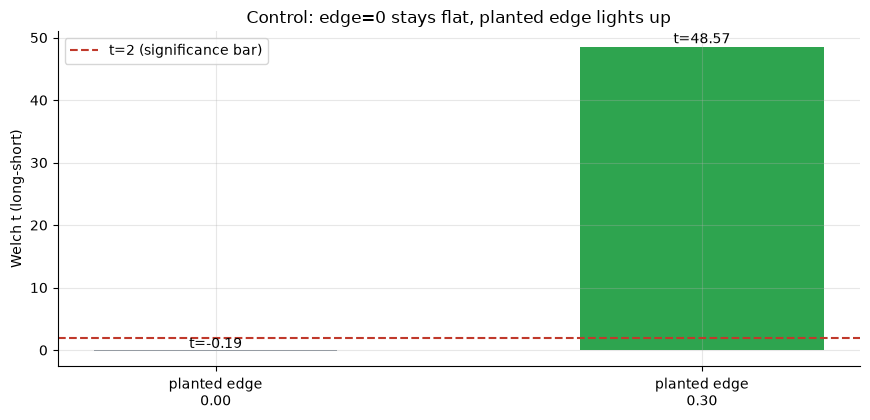

planted edge=0.00: ann=-0.3%  t=-0.19
planted edge=0.30: ann=107.1%  t=48.57


In [5]:
res = []
for edge in (0.0, 0.30):
    syn = data.synthetic_panel(edge=edge, seed=367)
    s = st.summarize(st.long_short_returns(syn['disc'], syn['ret'], min_names=6))
    res.append((edge, s['ann_mean']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e:.2f}' for e,_,_ in res]; tvals = [t for _,_,t in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t (long-short)'); ax.set_title('Control: edge=0 stays flat, planted edge lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,a,t in res: print(f'planted edge={e:.2f}: ann={a:.1f}%  t={t:.2f}')

> 💡 In plain words: with **no** real edge the control sits at **t = -0.19** (no false positive); a large planted edge reaches **t = 49**. So the machinery is honest — which means the real-tape **t = 3.72** is a property of the *data*, not the pipeline. The signal is really there.

## 5 · The verdict

- **Signal `REAL`** — long-short **+6.6%/yr** at Welch **t = 3.72** / bootstrap **p = 0.002**, β ≈ -0.00, placebo-clean. Clears the t ≥ 2 bar on the real tape. **Named caveats:** it's a *proxy* discount, a *survivor* basket (both inflate magnitude), and it **fades post-2010** — REAL, honestly bounded.
- **Tradability `FRAGILE`** — gross +6.6% → net **+1.8%/yr** (break-even 28 bps); the short leg is hard-to-borrow illiquid CEFs; capacity is tiny (18 small funds); modern-era t = 1.56. Survives on paper, not at scale.
- **Pays you to wait? `CONFIRMED`** — discount mean-reversion is genuinely real on the proxy; the catch is that the payment is small, costs-sensitive, short-constrained and fading. A measurable effect you can barely bank.

## 6 · Could you trade it? — the cost & borrow wall

The operational truth in one picture: gross spread, minus monthly two-leg costs, against the break-even cost. The margin is thin even before you price the **borrow** on a short leg of illiquid CEFs — which is where a real desk's version of this trade actually dies.

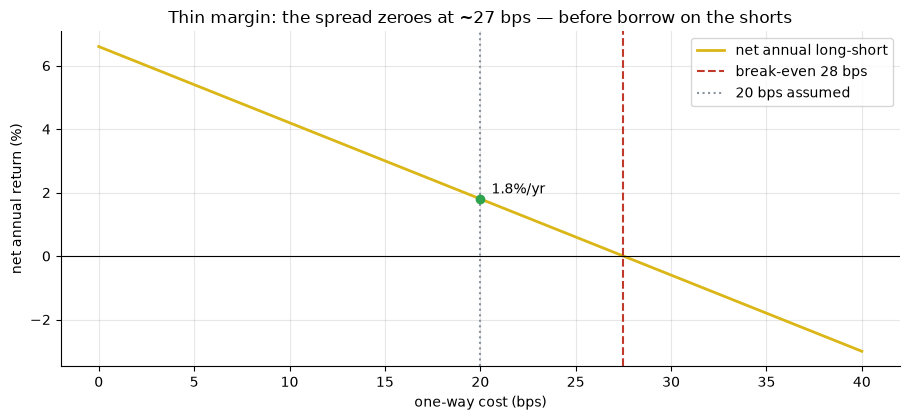

break-even ~28 bps one-way; at 20 bps net 1.8%/yr — and the short leg adds borrow on top


In [6]:
cost_grid = np.linspace(0, 40, 41)        # bps one-way
turnover = 2.0; gross_mo = R['ls'][0]/100
net_ann = (gross_mo - cost_grid/1e4*turnover)*12*100
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.plot(cost_grid, net_ann, c=AMBER, lw=2, label='net annual long-short')
ax.axhline(0, c='k', lw=.8)
ax.axvline(R['breakeven_bps'], c=RED, ls='--', label=f'break-even {R["breakeven_bps"]:.0f} bps')
ax.axvline(20, c=GREY, ls=':', label='20 bps assumed')
ax.scatter([20],[R['net_ann']], c=GREEN, zorder=5)
ax.annotate(f'{R["net_ann"]:.1f}%/yr', (20, R['net_ann']), textcoords='offset points', xytext=(8,4))
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net annual return (%)')
ax.set_title('Thin margin: the spread zeroes at ~27 bps — before borrow on the shorts')
ax.legend(); plt.tight_layout(); plt.show()
print(f'break-even ~{R["breakeven_bps"]:.0f} bps one-way; at 20 bps net {R["net_ann"]:.1f}%/yr — and the short leg adds borrow on top')

> 💡 In plain words: the net return hits zero at a one-way cost of just **28 bps** — a thin cushion for a strategy that rebalances both sleeves monthly. And the picture flatters reality, because it charges *nothing* for **borrowing the shorts**: narrow-discount CEFs are small, tightly held, and frequently **hard or impossible to borrow**, with fees that can exceed the entire spread. The long-only version sidesteps the borrow but keeps only ~half the return. Net of the real world, there is **no** sizing at which this becomes a scalable strategy — it is `REAL`, and it is `FRAGILE`, and the two are not in tension.

## 7 · Going further

- **Reported NAV.** Swap the benchmark proxy for each fund's true daily NAV (a CEF data vendor) — the discount sharpens and the placebo gap widens, but costs and the fade are untouched.
- **Kill survivorship.** Rebuild the universe with delisted/liquidated CEFs included (survivorship flatters a reversion bet); expect the magnitude — and possibly the modern-era _t_ — to drop further.
- **Borrow-aware backtest.** Attach a realistic, time-varying borrow fee to the short leg and a square-root market-impact model at the small CEFs' ADV; that is the test that decides whether *any* live version clears zero.

*The reproducible core is offline and deterministic; the discount input is an explicit proxy on a survivor basket. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*